In [48]:
from google.colab import files
files.upload()

Saving train.csv to train (5).csv


{'train (5).csv': b'experience,country,education,languages,frameworks,company_size,salary_usd\n34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292\n9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311\n8,USA,Some College,"C++, Go","Vue, React",5000+,109637\n29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386\n7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584\n13,USA,Bachelors,"Java, C++","React, ASP.NET",201-1000,121148\n31,UK,Bachelors,"Python, Rust","Flask, Angular",51-200,157919\n16,USA,Masters,"Go, Ruby","Angular, Angular",201-1000,155283\n11,USA,Masters,"Rust, C#","Laravel, Vue",11-50,114780\n27,Canada,Bachelors,"Python, Swift","ASP.NET, Ruby on Rails",5000+,139982\n39,India,High School,"C++, Swift","Express, React",1-10,109902\n18,USA,Masters,"JavaScript, C#","Laravel, ASP.NET",11-50,124517\n2,USA,Bachelors,"Java, Rust","ASP.NET, Ruby on Rails",1001-5000,112299\n25,India,Masters,"C#, C++","Ruby on Rails, Flask",5000+,96139\n29,USA,Bach

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
data=pd.read_csv("train.csv")
data.head(5)

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584


In [4]:
print(data.info())
print(data.describe())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    40000 non-null  int64 
 1   country       40000 non-null  object
 2   education     40000 non-null  object
 3   languages     40000 non-null  object
 4   frameworks    40000 non-null  object
 5   company_size  40000 non-null  object
 6   salary_usd    40000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB
None
         experience     salary_usd
count  40000.000000   40000.000000
mean      19.912875  131834.441525
std       11.865220   46426.249810
min        0.000000   12024.000000
25%       10.000000   98172.250000
50%       20.000000  130579.000000
75%       30.000000  164431.000000
max       40.000000  277554.000000
experience      0
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64


In [5]:
data.dropna()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584
...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,"Go, Java","ASP.NET, Vue",51-200,221009
39996,15,Brazil,Bachelors,"Ruby, Ruby","Django, ASP.NET",1001-5000,107678
39997,37,USA,Some College,"Rust, Python","ASP.NET, Ruby on Rails",11-50,195547
39998,27,USA,Masters,"Ruby, C++","Django, Express",1001-5000,204153


In [6]:
data.head()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584


In [7]:
size={
    "0-10":0,
    "11-50":1,
    "51-200":2,
    "201-1000":3,
    "1001-5000":4,
    "5000+":5,
}

data['company_size']=data['company_size'].map(size)

In [8]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
data['education']=le.fit_transform(data['education'])

In [9]:
data = pd.get_dummies(data, columns=["country"], drop_first=True)

In [10]:
data["languages"] = data["languages"].str.split(", ")
data["frameworks"] = data["frameworks"].str.split(", ")

In [11]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb_lang=MultiLabelBinarizer()
lang=mlb_lang.fit_transform(data['languages'])
mlb_frame=MultiLabelBinarizer()
frame=mlb_frame.fit_transform(data['frameworks'])

In [12]:
lang_df = pd.DataFrame(lang, columns=mlb_lang.classes_)
fw_df = pd.DataFrame(frame, columns=mlb_frame.classes_)

data = pd.concat([data, lang_df, fw_df], axis=1)
data = data.drop(columns=["languages", "frameworks"])

In [13]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experience         40000 non-null  int64  
 1   education          40000 non-null  int64  
 2   company_size       33472 non-null  float64
 3   salary_usd         40000 non-null  int64  
 4   country_Brazil     40000 non-null  bool   
 5   country_Canada     40000 non-null  bool   
 6   country_France     40000 non-null  bool   
 7   country_Germany    40000 non-null  bool   
 8   country_India      40000 non-null  bool   
 9   country_Japan      40000 non-null  bool   
 10  country_Singapore  40000 non-null  bool   
 11  country_UK         40000 non-null  bool   
 12  country_USA        40000 non-null  bool   
 13  C#                 40000 non-null  int64  
 14  C++                40000 non-null  int64  
 15  Go                 40000 non-null  int64  
 16  Java               400

,experience,education,company_size,salary_usd,C#,C++,Go,Java,JavaScript,PHP,...,ASP.NET,Angular,Django,Express,Flask,Laravel,React,Ruby on Rails,Spring,Vue
count,40000.000000,40000.000000,33472.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,19.912875,1.196950,3.002689,131834.441525,0.187900,0.190275,0.190125,0.190650,0.189275,0.188375,...,0.189125,0.188875,0.185725,0.190775,0.19240,0.190300,0.191575,0.192675,0.188450,0.188875
std,11.865220,1.364151,1.410191,46426.249810,0.390637,0.392523,0.392405,0.392819,0.391732,0.391016,...,0.391613,0.391414,0.388889,0.392917,0.39419,0.392543,0.393545,0.394405,0.391076,0.391414
min,0.000000,0.000000,1.000000,12024.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.000000,2.000000,98172.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,0.000000,3.000000,130579.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,2.000000,4.000000,164431.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,40.000000,4.000000,5.000000,277554.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


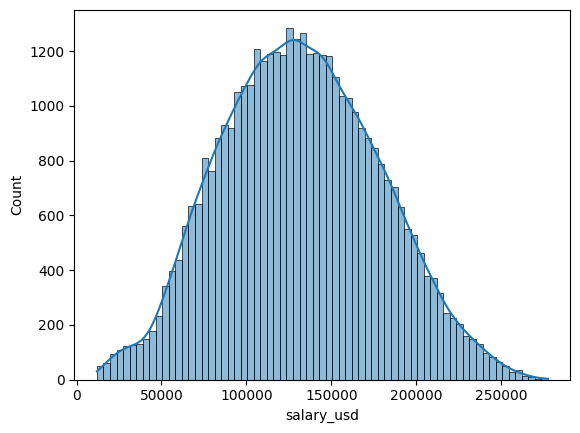

In [14]:
sns.histplot(data['salary_usd'],kde=True)
plt.show()

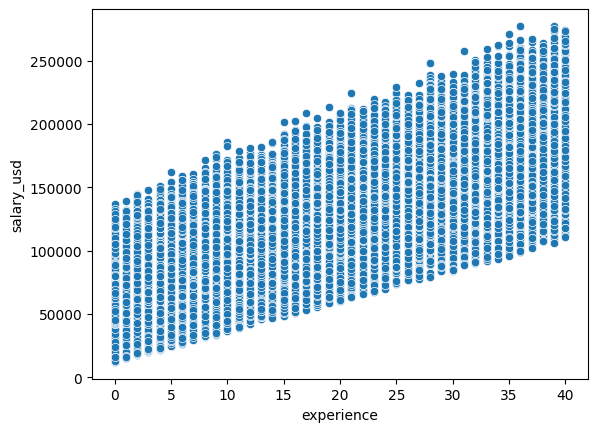

In [15]:
sns.scatterplot(x="experience", y="salary_usd", data=data)
plt.show()

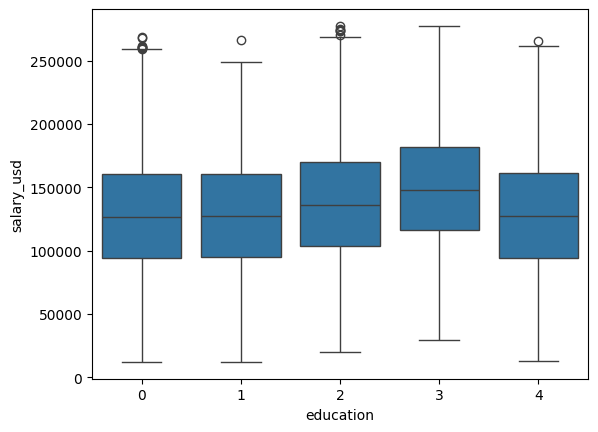

In [16]:
sns.boxplot(x="education", y="salary_usd", data=data)
plt.show()

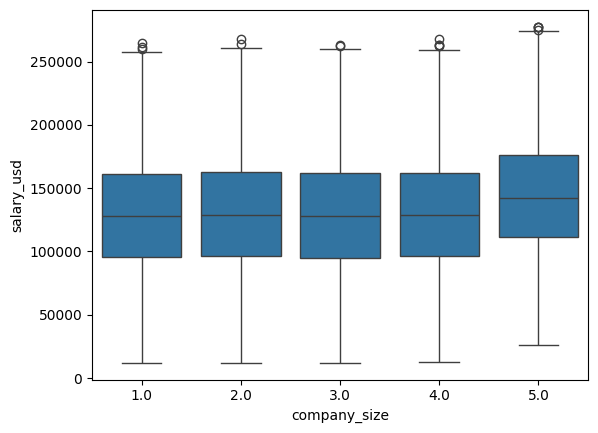

In [17]:
sns.boxplot(x="company_size", y="salary_usd", data=data)
plt.show()

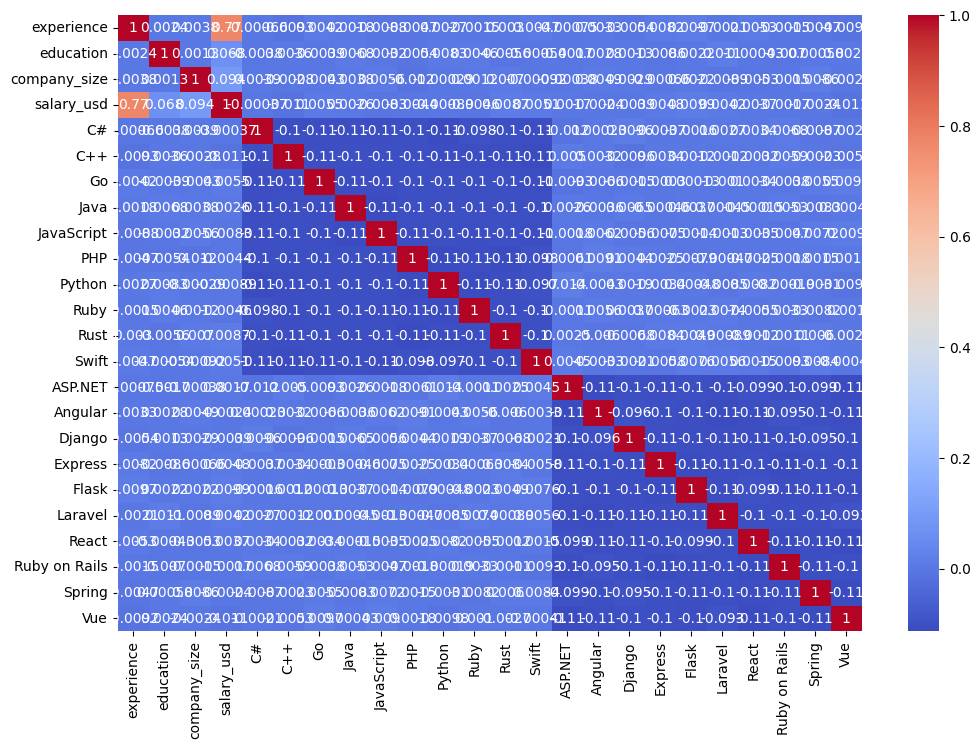

In [18]:
numeric_df = data.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.show()


In [29]:
from sklearn.model_selection import train_test_split
X=data.drop('salary_usd',axis=1)
y=data['salary_usd']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [58]:
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

In [31]:
y_pred = model.predict(X_test)

In [32]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 14210.748863572224
R2 Score: 0.85874517833938


In [34]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 14210.748863572224
R2 Score: 0.85874517833938


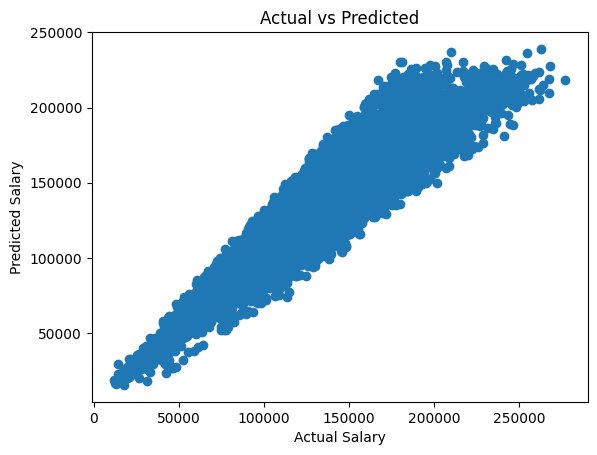

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

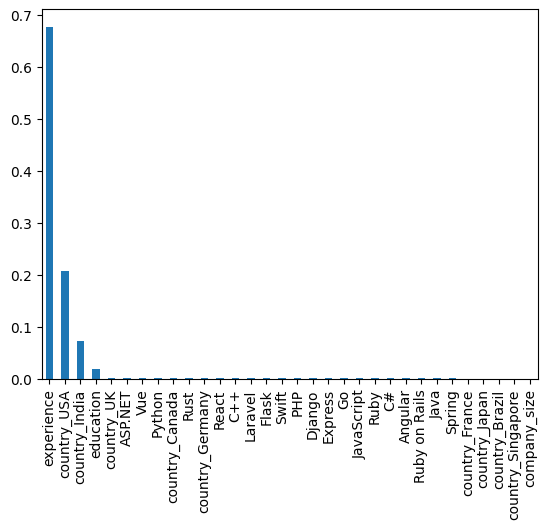

In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [54]:
data

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584
...,...,...,...,...,...,...,...
39995,38,USA,Bachelors,"Go, Java","ASP.NET, Vue",51-200,221009
39996,15,Brazil,Bachelors,"Ruby, Ruby","Django, ASP.NET",1001-5000,107678
39997,37,USA,Some College,"Rust, Python","ASP.NET, Ruby on Rails",11-50,195547
39998,27,USA,Masters,"Ruby, C++","Django, Express",1001-5000,204153


In [43]:
X = X.fillna(X.mean())

ValueError: Found array with 0 sample(s) (shape=(0, 32)) while a minimum of 1 is required by SimpleImputer.

In [55]:
print(data.shape)

(40000, 7)


In [56]:
new_data = [[2, 1, 25]]

In [61]:
import pandas as pd

# Step 1: Create empty dataframe with ALL columns
new_data = pd.DataFrame(columns=X.columns)

# Step 2: Initialize all values to 0
new_data.loc[0] = 0

# Step 3: Fill your input values

# Basic features
new_data['experience'] = 3
new_data['education'] = 1
new_data['company_size'] = 2

# Country (one-hot)
new_data['country_India'] = 1

# Skills (one-hot)
new_data['Python'] = 1
new_data['Django'] = 1

# Step 4: Predict
prediction = model.predict(new_data)

print("Predicted Salary:", prediction[0])

Predicted Salary: 27927.55108564656


In [60]:
print(X.columns)

Index(['experience', 'education', 'company_size', 'country_Brazil',
       'country_Canada', 'country_France', 'country_Germany', 'country_India',
       'country_Japan', 'country_Singapore', 'country_UK', 'country_USA', 'C#',
       'C++', 'Go', 'Java', 'JavaScript', 'PHP', 'Python', 'Ruby', 'Rust',
       'Swift', 'ASP.NET', 'Angular', 'Django', 'Express', 'Flask', 'Laravel',
       'React', 'Ruby on Rails', 'Spring', 'Vue'],
      dtype='object')


In [65]:
import pandas as pd

def predict_salary(exp, edu, size, country, skills):
    new_data = pd.DataFrame(columns=X.columns)
    new_data.loc[0] = 0

    # Basic features
    new_data['experience'] = exp
    new_data['education'] = edu
    new_data['company_size'] = size

    # Country (one-hot)
    new_data[f'country_{country}'] = 1

    # Skills (one-hot)
    for skill in skills:
        if skill in new_data.columns:
            new_data[skill] = 1

    return model.predict(new_data)[0]

In [66]:
print(predict_salary(1, 1, 1, "India", ["Python"]))
print(predict_salary(5, 2, 3, "USA", ["Python", "React"]))
print(predict_salary(8, 3, 4, "Germany", ["Java", "Spring"]))

24263.742989912633
115830.7458393686
100745.276300237


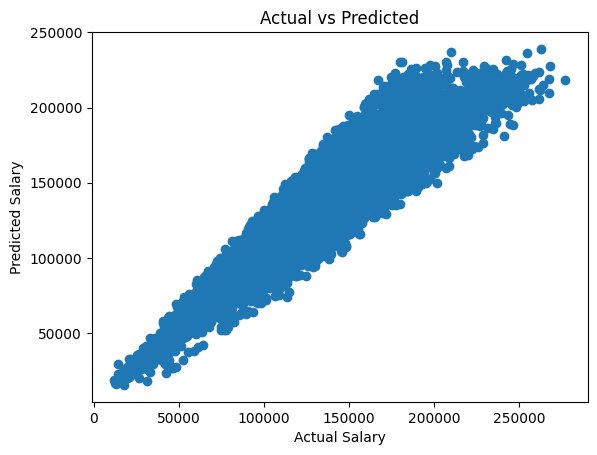

In [67]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [68]:
import joblib

joblib.dump(model, "salary_model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [71]:
from google.colab import files
files.download("columns.pkl")
files.download("salary_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>